In [6]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from pathlib import Path
import os

In [7]:
WD_PATH = Path(f"{os.getcwd()}")
print(WD_PATH)

/home/awelch/GIPL/O_warming_experiment/spin_up


In [9]:
def find_stable_year(df, depth_col):
    days_in_year = 365  # Assuming non-leap years for simplicity
    threshold = 0.1

    for start_year in range(len(df) // days_in_year - 1):  # Ensure we have at least two full years of data
        start_index = start_year * days_in_year
        stable = True

        for day in range(days_in_year):
            current_year_temp = df.iloc[start_index + day][depth_col]
            next_year_temp = df.iloc[start_index + days_in_year + day][depth_col]

            if abs(current_year_temp - next_year_temp) >= threshold:
                stable = False
                break

        if stable:
            return start_year

    return None

def check_stability_in_year(df, year, depth_col):
    days_in_year = 365
    threshold = 0.1
    start_index = year * days_in_year

    for day in range(days_in_year):
        current_year_temp = df.iloc[start_index + day][depth_col]
        next_year_temp = df.iloc[start_index + days_in_year + day][depth_col]

        if abs(current_year_temp - next_year_temp) >= threshold:
            return False

    return True

def find_all_depths_stable_year(df, depth_cols):
    days_in_year = 365
    start_year = 0

    while start_year < len(df) // days_in_year - 1:
        stable = True

        for depth_col in depth_cols:
            if not check_stability_in_year(df, start_year, depth_col):
                stable = False
                break

        if stable:
            return start_year

        start_year += 1

    return None

def print_last_row_of_stable_year(df, stable_year):
    days_in_year = 365
    row_id = (stable_year + 1) * days_in_year  # Row ID for the last day of the stable year
    last_row = df.iloc[row_id - 1]  # -1 because row indices are zero-based
    print(f"\nLast row of stable year {stable_year + 1}:")
    print(last_row)

# Load your data (adjust the file path as needed)
calc_header = ['id', 'time', 'Tair', 'snow', '0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']
temperature_data = pd.read_csv(WD_PATH / 'out/result.txt', sep=r'\s+', names=calc_header)

# Dictionary to store results
stable_years = {}

# Loop through each depth column and apply the function
for depth_col in calc_header[4:]:  # From column 4 to 10
    stable_year = find_stable_year(temperature_data, depth_col)
    
    if stable_year is not None:
        stable_years[depth_col] = stable_year
        print(f"Stable year found for depth {depth_col}: Year {stable_year + 1}")
    else:
        print(f"No stable year found for depth {depth_col}")

# Find the year when all depths are stable
all_depths_stable_year = find_all_depths_stable_year(temperature_data, calc_header[4:])

if all_depths_stable_year is not None:
    print(f"\nAll depths are stable in Year {all_depths_stable_year + 1}")
    
    # Print the last row of the stable year
    print_last_row_of_stable_year(temperature_data, all_depths_stable_year)
else:
    print("No single year found where all depths are stable.")


Stable year found for depth 0.01m: Year 10
Stable year found for depth 0.08m: Year 12
Stable year found for depth 0.13m: Year 14
Stable year found for depth 0.24m: Year 11
Stable year found for depth 0.38m: Year 11
Stable year found for depth 0.53m: Year 11
Stable year found for depth 0.67m: Year 11

All depths are stable in Year 24

Last row of stable year 24:
id          1.000000
time     8760.000000
Tair      -18.600000
snow        0.500000
0.01m      -3.394673
0.08m      -2.439834
0.13m      -2.087391
0.24m      -1.626985
0.38m      -1.042829
0.53m      -0.636287
0.67m      -0.324912
Name: 8759, dtype: float64


Text(0.5, 1.0, 'Calculated ground temperatures ')

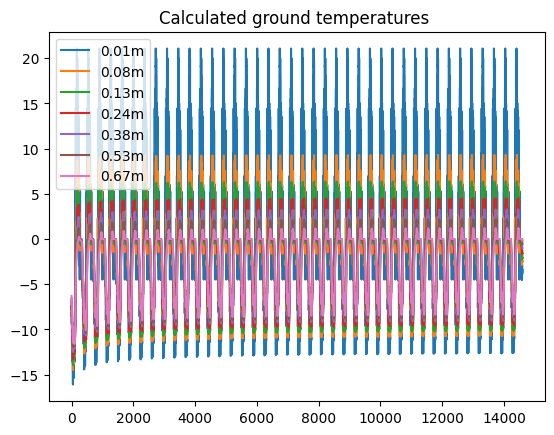

In [5]:
def load_calc():
    calc_file=WD_PATH/'out/result.txt'
    calc_data = np.loadtxt(calc_file, skiprows=0,  unpack=False)
    calc_header=['id','time','Tair','snow','0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m' ]
    df = pd.DataFrame(calc_data, columns=calc_header) 
    return df

df_calc = load_calc()

df_calc[['0.01m', '0.08m', '0.13m', '0.24m', '0.38m', '0.53m', '0.67m']].plot()
plt.title('Calculated ground temperatures ')